BE Model Recovery Analysis - Basic Workflows
=============================================

This script demonstrates the basic recovery analysis workflows available
in the SC_behaviour_analysis package.

Contents:
1. Setup and Imports
2. Basic Model Simulation
3. Psychometric Curve Analysis
4. Burn-in Effects on Behaviour
5. Burn-in Recovery Analysis
6. MixedAgent Analysis
7. Schema Detection Validation (MixedAgent sweep)

Run sections interactively in Jupyter/IPython or as a script.

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Core imports
from Helpers.utils import generate_stimuli, cumulative_gaussian
from Helpers.psychometry import fit_psychometric, compute_psychometric_gof

# Models
from Models.BE_model import BoundaryEstimationModel
from Models.agent import MixedAgent

# Plotting
from Plotting.psychometric import plot_psychometric, plot_psychometric_grid, plot_psychometric_comparison
from Plotting.belief import plot_belief_distribution, plot_belief_distributions
from Plotting.recovery import plot_burn_in_recovery, plot_burn_in_param_distributions

# Analysis
from Param_recovery.BE_agent_recovery import (
    burn_in_recovery_analysis,
    burn_in_recovery_summary_stats,
    plot_psychometric_by_burn_in,
    plot_belief_after_burn_in
)

print("All imports successful!")

All imports successful!


## 2. Basic Model Simulation - True Model

Create a BE model, simulate a session, and visualise behaviour.


In [44]:
# Define model parameters
params = {
    'sigma_percep': 0.15,   # Perceptual noise
    'A_repulsion': 0.1,     # Serial dependence (repulsion)
    'mu_learning': 0.35,    # Learning rate
    'mu_relax': 0.12        # Relaxation rate
}

# Create model
model = BoundaryEstimationModel(**params) #type: ignore

# Initialise with burn-in (expert-like starting point)
model.reset_belief(burn_in=1000, burn_in_seed=42)

# Generate stimuli
stimuli, categories, rng = generate_stimuli(n_trials=300, seed=42)

# Simulate session
choices, p_B = model.simulate_session(stimuli, categories, rng=rng)

# Basic metrics
accuracy = np.mean(choices == categories)
print(f"Accuracy: {accuracy:.1%}")
print(f"P(choose B): {np.mean(choices):.2f}")

Accuracy: 81.0%
P(choose B): 0.51


## 3. Psychometric Curve Analysis -  True Model

Fit and visualise psychometric curves.


Psychometric parameters:
  PSE (μ): -0.043
  Slope (σ): 0.469
  Lapse low: 0.000
  Lapse high: 0.000

Goodness of fit:
  R²: 0.984
  RMSE: 0.043
  Deviance explained: 0.420


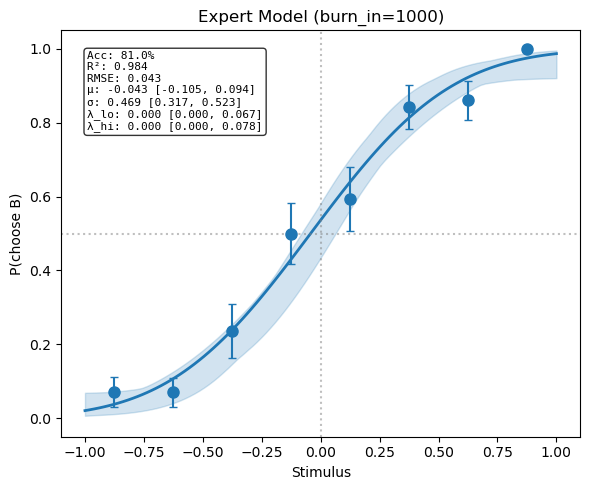

In [45]:
# Single psychometric plot
fig, ax = plt.subplots(figsize=(6, 5))
ax, info = plot_psychometric(
    stimuli, choices, 
    ax=ax, 
    show_gof=True,
    show_lapse=True,
    title='Expert Model (burn_in=1000)',
    n_bootstrap=10
)

print("\nPsychometric parameters:")
print(f"  PSE (μ): {info['psych_params']['mu']:.3f}")
print(f"  Slope (σ): {info['psych_params']['sigma']:.3f}")
print(f"  Lapse low: {info['psych_params']['lapse_low']:.3f}")
print(f"  Lapse high: {info['psych_params']['lapse_high']:.3f}")

print("\nGoodness of fit:")
print(f"  R²: {info['gof']['r_squared']:.3f}")
print(f"  RMSE: {info['gof']['rmse']:.3f}")
print(f"  Deviance explained: {info['gof']['deviance_explained']:.3f}")

plt.tight_layout()
plt.show()

## 4. Burn-in Effects on Behaviour - True Model

Visualise how behaviour changes from naive (burn_in=0) to expert (high burn_in).

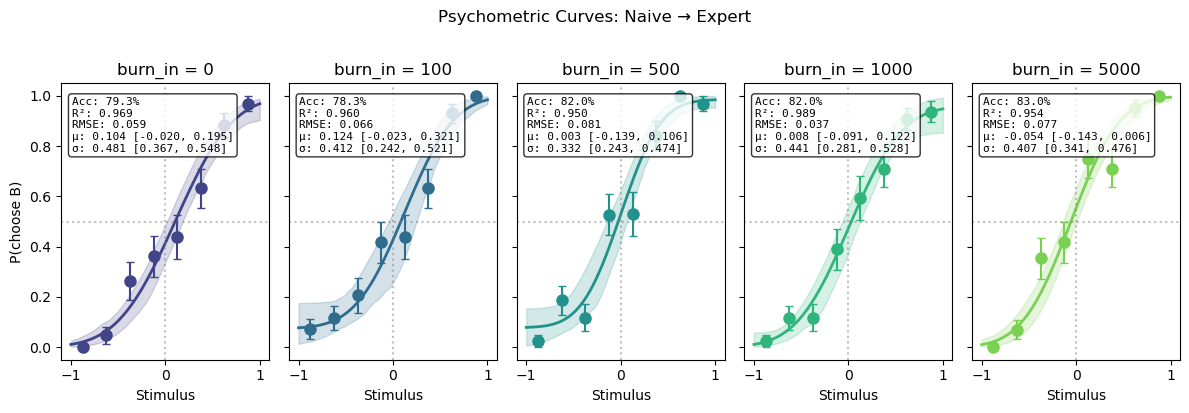


Goodness-of-fit summary:
 burn_in  accuracy        mu    sigma  r_squared
       0  0.793333  0.103686 0.480767   0.968859
     100  0.783333  0.124446 0.411688   0.960026
     500  0.820000  0.003408 0.332135   0.949957
    1000  0.820000  0.008147 0.441308   0.988541
    5000  0.830000 -0.054491 0.406983   0.953985


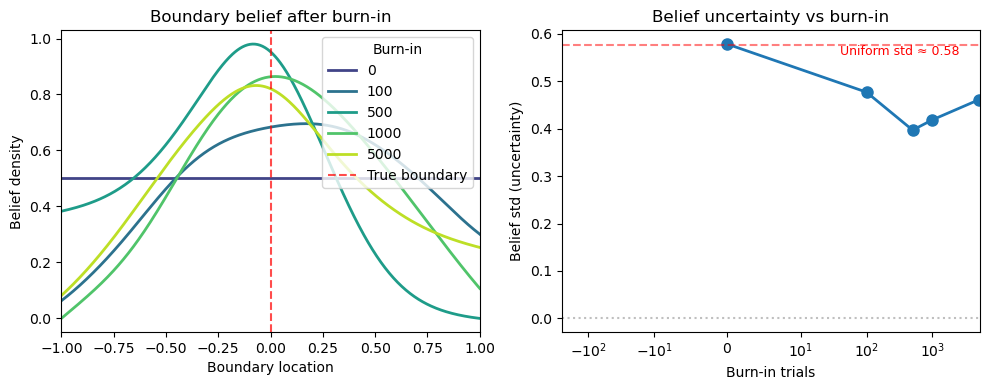

In [ ]:
# Psychometric curves across burn-in levels
fig1, gof_df = plot_psychometric_by_burn_in(
    params,
    burn_in_values=[0, 100, 500, 1000, 5000],
	show_gof=True,
    show_params=True,
    # show_lapse=True,
    n_bootstrap=100,
    show_ci=True,
    n_trials=300,
    seed=42,
)
fig1.suptitle('Psychometric Curves: Naive → Expert', y=1.02)
plt.tight_layout()
plt.show()

print("\nGoodness-of-fit summary:")
print(gof_df[['burn_in', 'accuracy', 'mu', 'sigma', 'r_squared']].to_string(index=False))

# %%
# Belief distribution evolution
fig2 = plot_belief_after_burn_in(
    params,
    burn_in_values=[0, 100, 500, 1000, 5000],
    seed=42
)
plt.tight_layout()
plt.show()


## 5. Burn-in Recovery Analysis

Test how well parameters can be recovered when the fitter assumes
naive starting point but the true model has varying experience levels.
 
**Key question**: If we fit a model assuming the animal is naive (burn_in=0),
how wrong are our parameter estimates when the animal is actually experienced?

In [33]:
# Run recovery analysis (this takes a few minutes)
print("Running burn-in recovery analysis...")
print("This tests parameter recovery across different burn-in conditions.")
print("Fitter always assumes burn_in=0 (naive).\n")

results = burn_in_recovery_analysis(
    true_params=params,
    burn_in_values=[0, 
                    # 100, 500, 1000, 
                    5000],
    n_trials=300,
    n_replicates=20,  
    fitter_burn_in=0,  # Fitter assumes naive
    validation='holdout',
    seed=42,
    verbose=True
)

Running burn-in recovery analysis...
This tests parameter recovery across different burn-in conditions.
Fitter always assumes burn_in=0 (naive).


Testing burn_in = 0
  Replicate 1/20... OK
  Replicate 2/20... OK
  Replicate 3/20... OK
  Replicate 4/20... OK
  Replicate 5/20... OK
  Replicate 6/20... OK
  Replicate 7/20... OK
  Replicate 8/20... OK
  Replicate 9/20... OK
  Replicate 10/20... OK
  Replicate 11/20... OK
  Replicate 12/20... OK
  Replicate 13/20... OK
  Replicate 14/20... OK
  Replicate 15/20... OK
  Replicate 16/20... OK
  Replicate 17/20... OK
  Replicate 18/20... OK
  Replicate 19/20... OK
  Replicate 20/20... OK

Testing burn_in = 5000
  Replicate 1/20... OK
  Replicate 2/20... OK
  Replicate 3/20... OK
  Replicate 4/20... OK
  Replicate 5/20... OK
  Replicate 6/20... OK
  Replicate 7/20... OK
  Replicate 8/20... OK
  Replicate 9/20... OK
  Replicate 10/20... OK
  Replicate 11/20... OK
  Replicate 12/20... OK
  Replicate 13/20... OK
  Replicate 14/20... OK
  Replicate

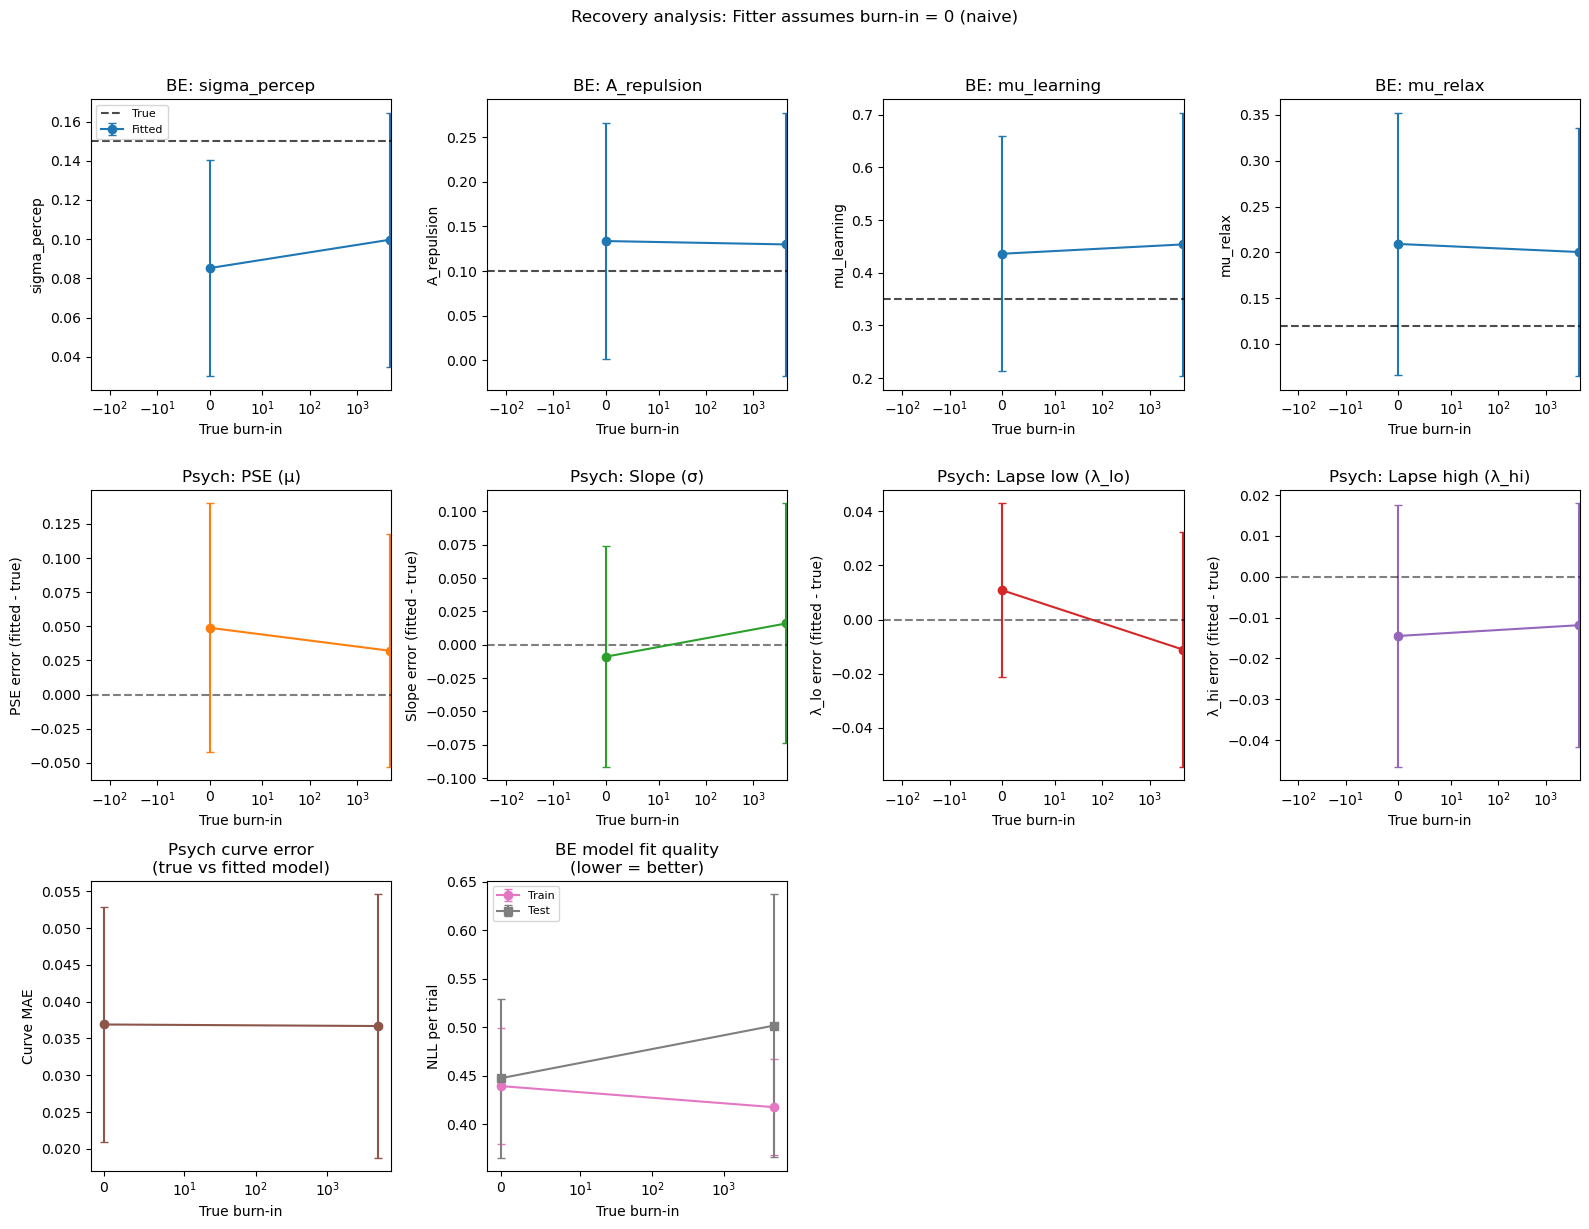

In [34]:
# Plot recovery results
fig = plot_burn_in_recovery(results)
plt.tight_layout()
plt.show()

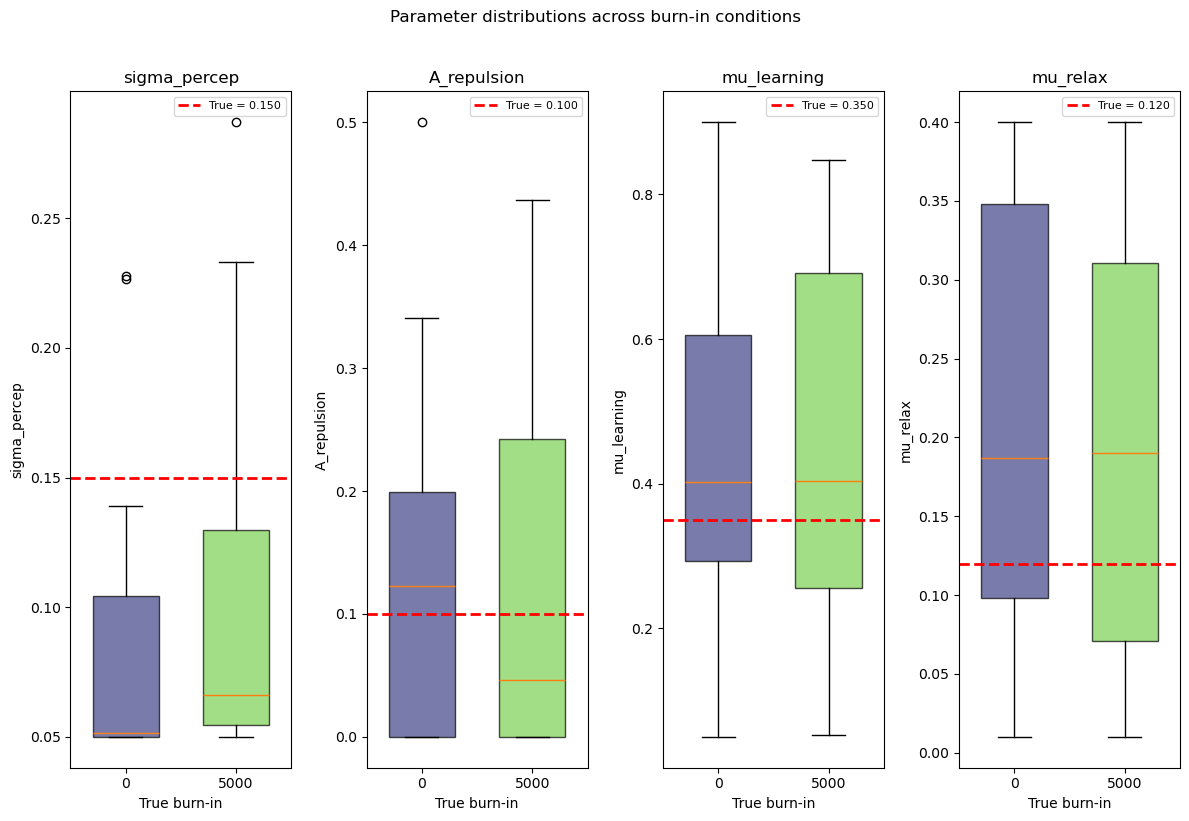

In [35]:
# Parameter distributions
fig = plot_burn_in_param_distributions(results)
plt.tight_layout()
plt.show()

In [36]:
# Summary statistics table
df = burn_in_recovery_summary_stats(results)
print("\nRecovery Summary:")
print(df.round(4).to_string(index=False))


Recovery Summary:
 burn_in  sigma_percep_true  sigma_percep_mean  sigma_percep_std  sigma_percep_bias  sigma_percep_abs_error  A_repulsion_true  A_repulsion_mean  A_repulsion_std  A_repulsion_bias  A_repulsion_abs_error  mu_learning_true  mu_learning_mean  mu_learning_std  mu_learning_bias  mu_learning_abs_error  mu_relax_true  mu_relax_mean  mu_relax_std  mu_relax_bias  mu_relax_abs_error  psych_mu_bias  psych_mu_std  psych_sigma_bias  psych_sigma_std  psych_lapse_low_bias  psych_lapse_low_std  psych_lapse_high_bias  psych_lapse_high_std  psych_curve_mae  train_nll_mean  test_nll_mean
       0               0.15             0.0852            0.0552            -0.0648                  0.0802               0.1            0.1336           0.1323            0.0336                 0.1038              0.35            0.4361           0.2235            0.0861                 0.1846           0.12         0.2092        0.1435         0.0892              0.1374         0.0489        0.0912   

In [37]:
# Key insight: Look at mu_learning bias as burn-in increases
print("\n\nKey finding - mu_learning bias by burn-in:")
for burn_in in results['config']['burn_in_values']:
    bias = results['param_recovery'][burn_in]['mu_learning']['mean_error']
    print(f"  burn_in={burn_in:5d}: bias = {bias:+.4f}")



Key finding - mu_learning bias by burn-in:
  burn_in=    0: bias = +0.0861
  burn_in= 5000: bias = +0.1038


## 6. MixedAgent Analysis

The MixedAgent combines BE model with heuristic strategies.
This is useful for:
- Modelling naive animals who use heuristics before learning the task schema
- Validating that BE model fitting fails for heuristic-dominated behaviour
 
P(B) = α × P(B|BE) + (1-α) × P(B|heuristics)
 
Where heuristics include: side bias, win-stay, lose-shift, random


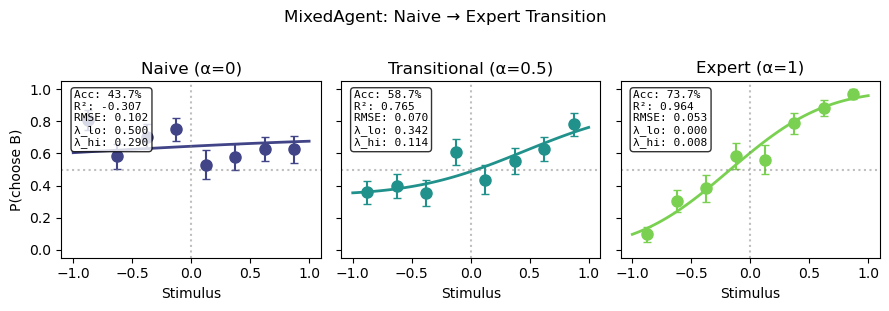


Agent comparison:
  Naive       : Acc=43.7%, μ=-1.000, σ=2.000
  Transitional: Acc=58.7%, μ=0.453, σ=0.730
  Expert      : Acc=73.7%, μ=-0.175, σ=0.634


In [38]:
# Create and simulate different agent types

stimuli, categories, rng = generate_stimuli(n_trials=300, seed=42)

# Pure BE model (expert)
agent_expert = MixedAgent(
    alpha=1.0,           # 100% BE model
    mu_learning=0.35,
    burn_in=1000,
    burn_in_seed=42
)

# Pure heuristic (naive, no schema)
agent_naive = MixedAgent(
    alpha=0.0,           # 100% heuristics
    bias=0.4,           # Slight preference for B
    p_winstay=0.7,       # Repeat after reward
    p_loseshift=0.5,     # Random after no reward
)

# Mixed (transitional)
agent_transitional = MixedAgent(
    alpha=0.5,           # 50/50 mix
    mu_learning=0.35,
    bias=0.1,
    p_winstay=0.6,
    burn_in=500
)

# Simulate
choices_expert, _ = agent_expert.simulate_session(stimuli, categories, rng=np.random.default_rng(42))
choices_naive, _ = agent_naive.simulate_session(stimuli, categories, rng=np.random.default_rng(42))

agent_transitional.reset()
choices_trans, _ = agent_transitional.simulate_session(stimuli, categories, rng=np.random.default_rng(42))

# Compare
fig, infos = plot_psychometric_grid(
    [stimuli, stimuli, stimuli],
    [choices_naive, choices_trans, choices_expert],
    labels=['Naive (α=0)', 'Transitional (α=0.5)', 'Expert (α=1)'],
    show_lapse=True,
    ncols=3,
    show_gof=True
)
fig.suptitle('MixedAgent: Naive → Expert Transition', y=1.02)
plt.tight_layout()
plt.show()

# Summary
print("\nAgent comparison:")
for name, choices in [('Naive', choices_naive), ('Transitional', choices_trans), ('Expert', choices_expert)]:
    acc = np.mean(choices == categories)
    psych = fit_psychometric(stimuli, choices)
    print(f"  {name:12s}: Acc={acc:.1%}, μ={psych['mu']:.3f}, σ={psych['sigma']:.3f}")


In [40]:
# Detailed trial-by-trial output for single agent
agent = MixedAgent(alpha=0.5, mu_learning=0.35, bias=0.1, p_winstay=0.7, burn_in=500)
agent.reset()

stimuli_short, categories_short, rng_short = generate_stimuli(n_trials=20, seed=99)
df_detailed = agent.simulate_session_detailed(stimuli_short, categories_short, rng=rng_short)

print("\nDetailed trial-by-trial output (first 10 trials):")
print(df_detailed[['trial', 'stimulus', 'p_be', 'p_heuristic', 'p_mixed', 'choice', 'correct']].head(10).round(3).to_string(index=False))


Detailed trial-by-trial output (first 10 trials):
 trial  stimulus  p_be  p_heuristic  p_mixed  choice  correct
     0     0.012 0.770        0.550    0.660       0        0
     1     0.130 0.755        0.533    0.644       0        0
     2     0.024 0.502        0.533    0.518       0        0
     3     0.944 0.907        0.533    0.720       1        1
     4     0.230 0.598        0.600    0.599       1        1
     5     0.137 0.757        0.600    0.679       1        1
     6    -0.426 0.244        0.600    0.422       1        0
     7     0.109 0.827        0.533    0.680       1        1
     8    -0.065 0.298        0.600    0.449       1        0
     9     0.220 0.766        0.533    0.650       0        0


## 7. Schema Detection Validation

Key question: Can we detect when an animal is using BE model vs heuristics?
 
**Approach**: 
- Simulate agents with varying α (BE weight)
- Fit BE model to each
- Track psychometric R² and parameter estimates

**Prediction**: 
- Pure heuristic (α=0) should have poor R² or aberrant parameters
- Pure BE (α=1) should have good R² and sensible parameters

In [41]:
# Sweep across alpha values
alphas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
n_replicates = 5

results_list = []

print("Running alpha sweep...")
for alpha in alphas:
    for rep in range(n_replicates):
        # Generate fresh stimuli per replicate
        stim, cats, rng = generate_stimuli(n_trials=300, seed=1000*int(alpha*10) + rep)
        
        # Create agent
        agent = MixedAgent(
            alpha=alpha,
            mu_learning=0.35,
            bias=0.15,
            p_winstay=0.7,
            p_loseshift=0.5,
            burn_in=500,
            burn_in_seed=42
        )
        
        # Simulate
        choices, _ = agent.simulate_session(stim, cats, rng=rng)
        
        # Fit psychometric
        psych = fit_psychometric(stim, choices)
        gof = compute_psychometric_gof(stim, choices, psych)
        
        # Store results
        results_list.append({
            'alpha': alpha,
            'replicate': rep,
            'accuracy': np.mean(choices == cats),
            'mu': psych.get('mu', np.nan),
            'sigma': psych.get('sigma', np.nan),
            'r_squared': gof['r_squared'],
            'rmse': gof['rmse'],
            'deviance_explained': gof['deviance_explained']
        })
    print(f"  α={alpha} complete")

df_sweep = pd.DataFrame(results_list)

Running alpha sweep...
  α=0.0 complete
  α=0.2 complete
  α=0.4 complete
  α=0.6 complete
  α=0.8 complete
  α=1.0 complete


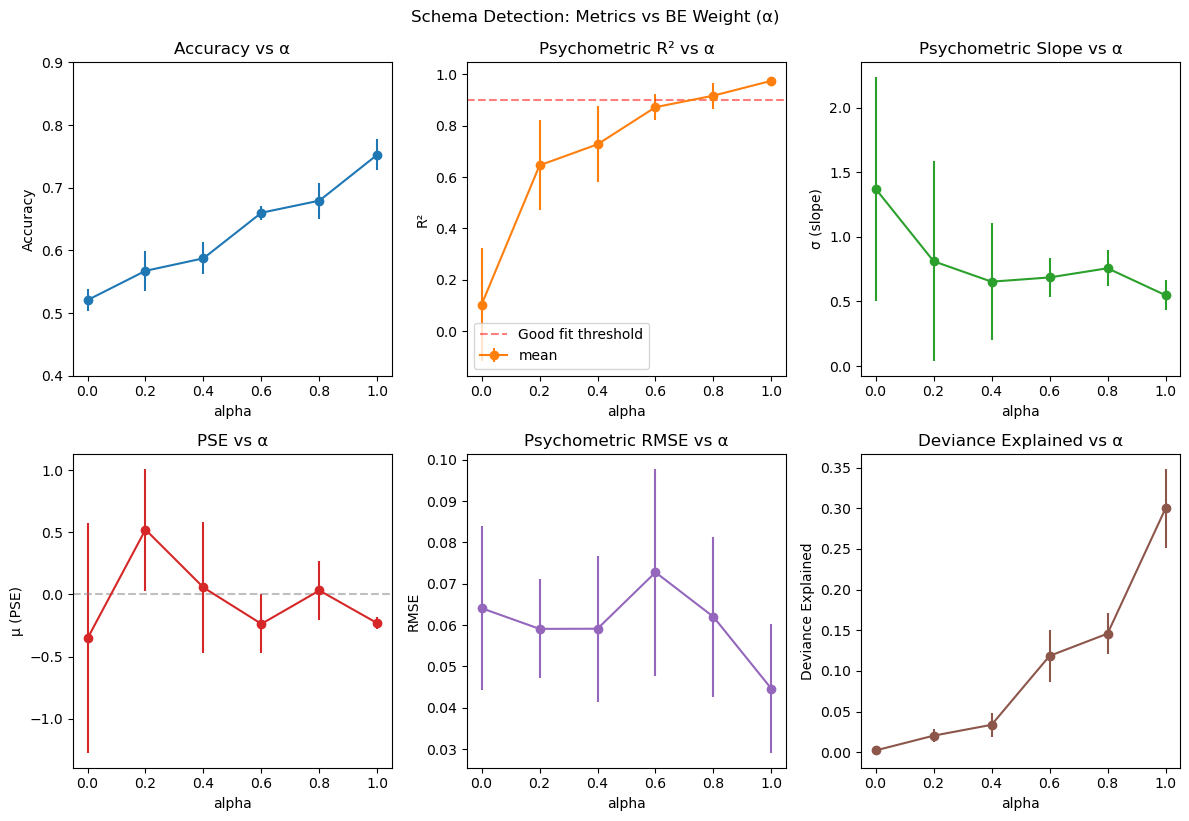

In [42]:
# Visualise sweep results
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Accuracy
ax = axes[0, 0]
df_sweep.groupby('alpha')['accuracy'].agg(['mean', 'std']).plot(
    y='mean', yerr='std', marker='o', ax=ax, legend=False
)
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs α')
ax.set_ylim(0.4, 0.9)

# R²
ax = axes[0, 1]
df_sweep.groupby('alpha')['r_squared'].agg(['mean', 'std']).plot(
    y='mean', yerr='std', marker='o', ax=ax, legend=False, color='C1'
)
ax.set_ylabel('R²')
ax.set_title('Psychometric R² vs α')
ax.axhline(0.9, color='red', linestyle='--', alpha=0.5, label='Good fit threshold')
ax.legend()

# Sigma (slope)
ax = axes[0, 2]
df_sweep.groupby('alpha')['sigma'].agg(['mean', 'std']).plot(
    y='mean', yerr='std', marker='o', ax=ax, legend=False, color='C2'
)
ax.set_ylabel('σ (slope)')
ax.set_title('Psychometric Slope vs α')

# PSE
ax = axes[1, 0]
df_sweep.groupby('alpha')['mu'].agg(['mean', 'std']).plot(
    y='mean', yerr='std', marker='o', ax=ax, legend=False, color='C3'
)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('μ (PSE)')
ax.set_title('PSE vs α')

# RMSE
ax = axes[1, 1]
df_sweep.groupby('alpha')['rmse'].agg(['mean', 'std']).plot(
    y='mean', yerr='std', marker='o', ax=ax, legend=False, color='C4'
)
ax.set_ylabel('RMSE')
ax.set_title('Psychometric RMSE vs α')

# Deviance explained
ax = axes[1, 2]
df_sweep.groupby('alpha')['deviance_explained'].agg(['mean', 'std']).plot(
    y='mean', yerr='std', marker='o', ax=ax, legend=False, color='C5'
)
ax.set_ylabel('Deviance Explained')
ax.set_title('Deviance Explained vs α')

plt.tight_layout()
plt.suptitle('Schema Detection: Metrics vs BE Weight (α)', y=1.02)
plt.show()

In [14]:
# Summary table
print("\nAlpha Sweep Summary:")
summary = df_sweep.groupby('alpha').agg({
    'accuracy': ['mean', 'std'],
    'r_squared': ['mean', 'std'],
    'sigma': ['mean', 'std'],
    'mu': ['mean', 'std']
}).round(3)
print(summary.to_string())


Alpha Sweep Summary:
      accuracy        r_squared         sigma            mu       
          mean    std      mean    std   mean    std   mean    std
alpha                                                             
0.0      0.521  0.018     0.103  0.222  1.371  0.869 -0.354  0.925
0.2      0.567  0.032     0.646  0.175  0.811  0.775  0.521  0.491
0.4      0.587  0.026     0.728  0.149  0.653  0.453  0.055  0.528
0.6      0.660  0.011     0.873  0.051  0.686  0.149 -0.237  0.238
0.8      0.679  0.029     0.918  0.050  0.757  0.139  0.031  0.236
1.0      0.753  0.025     0.975  0.016  0.549  0.118 -0.232  0.047
